In [1]:
# Python Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS

from pyprojroot import here
workspace_path = str(here())
%cd $workspace_path
print(f"Working Directory has been set to `{workspace_path}`")

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline

/home/joao/Documents/Research/4_sys_analysis
Working Directory has been set to `/home/joao/Documents/Research/4_sys_analysis`


2021-07-19 14:43:06,368 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autofit/config


2021-07-19 14:43:16,291 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autoarray/config
2021-07-19 14:43:16,919 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autogalaxy/config
2021-07-19 14:43:17,179 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autolens/config


## Def Functions

In [2]:
# Img blocks Paths
imgblocks_paths = "./imgblocks/"
grid_scale = 0.1
def prepare_data(pos):
    new_pos = (np.array(pos) - 75.5)*grid_scale # 75.5 to normalize (center in (0,0))
    return new_pos

## CS82SL013639.16+000818.38

In [3]:
img_name = "imgblock1.fits"
sys_path = "./LOG/sys_1_ci/"

### Lens System

In [4]:
images = [[66.9578, 91.0704], [59.9249, 82.0282], [69.6369, 61.2645], [95.0892, 76.]]
noise_map = [0.05, 0.5, 0.5, 0.5]

image_pos = prepare_data(images)

In [5]:
image = al.Array2D.from_fits(
    file_path=imgblocks_paths+img_name, pixel_scales=grid_scale, hdu=3
)

In [6]:
image_pos_cat = al.PointDataset(name="point_0",
                                positions = al.Grid2DIrregular(image_pos),
                                positions_noise_map = al.ValuesIrregular(noise_map)
                        )

point_dict = al.PointDict(point_dataset_list=[image_pos_cat])

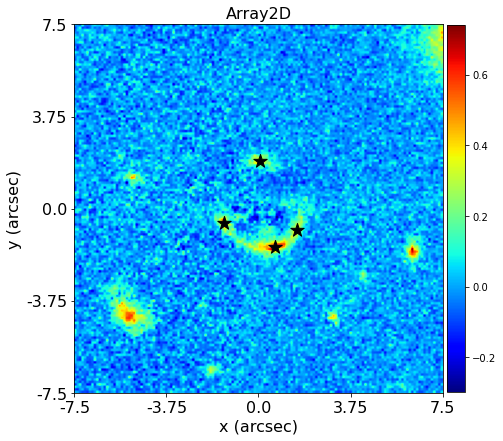

In [7]:
visuals_2d = aplt.Visuals2D(positions=point_dict.positions_list)

array_plotter = aplt.Array2DPlotter(array=image, visuals_2d=visuals_2d)
array_plotter.figure_2d()

### Inverse modeling

In [8]:
# lens model
lens = af.Model(al.Galaxy, redshift=0.3440, mass=al.mp.EllIsothermal)
# source model
source = af.Model(al.Galaxy, redshift=1.0, point_0=al.ps.Point)
# model
model = af.Collection(galaxies=af.Collection(lens=lens, source=source))

In [9]:
# commom 2d grid, it uses the image's grid
grid = al.Grid2D.uniform(
    shape_native=image.shape_native, pixel_scales=image.pixel_scales
)
# looks like an initial guess for our image positions
positions_solver = al.PositionsSolver(grid=grid, pixel_scale_precision=0.1)

In [10]:
# model path and cores for fit
search = af.DynestyStatic(
    path_prefix="./",
    name="sys1",
    nlive=50,
    number_of_cores=4,
)

2021-07-19 14:43:19,439 - sys1 - INFO - Creating search


In [11]:
# fit our model
analysis = al.AnalysisPoint(point_dict=point_dict, solver=positions_solver)
result = search.fit(model=model, analysis=analysis)

2021-07-19 14:43:19,560 - sys1 - INFO - Starting search
2021-07-19 14:43:19,813 - sys1 - INFO - Already completed, skipping non-linear search.
2021-07-19 14:43:19,818 - sys1 - INFO - Removing zip file


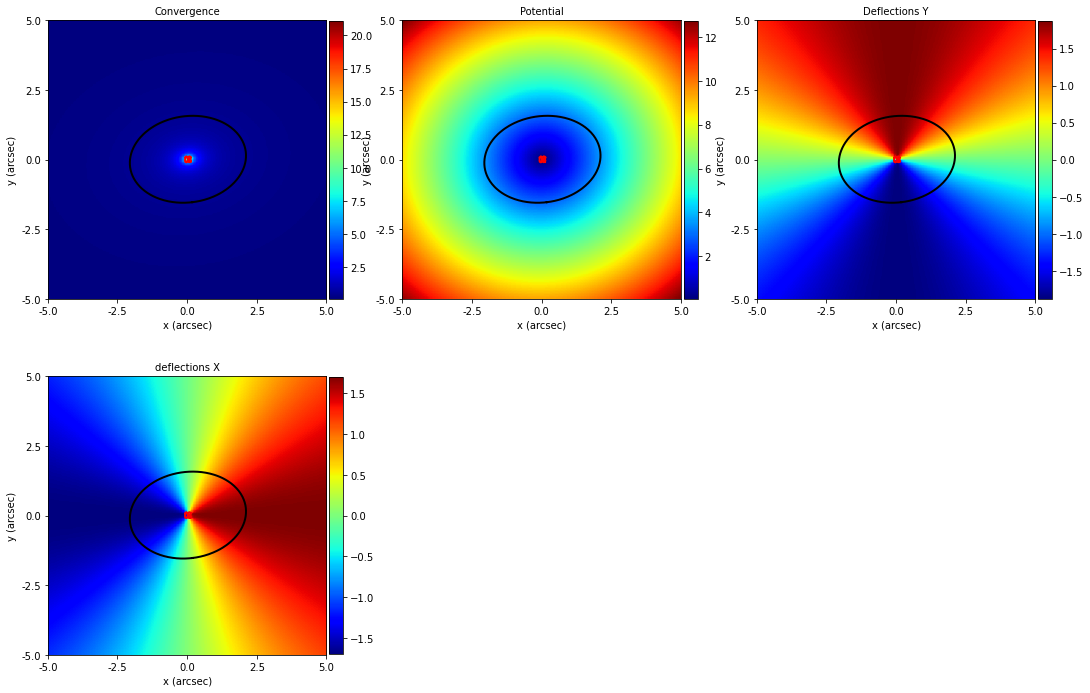

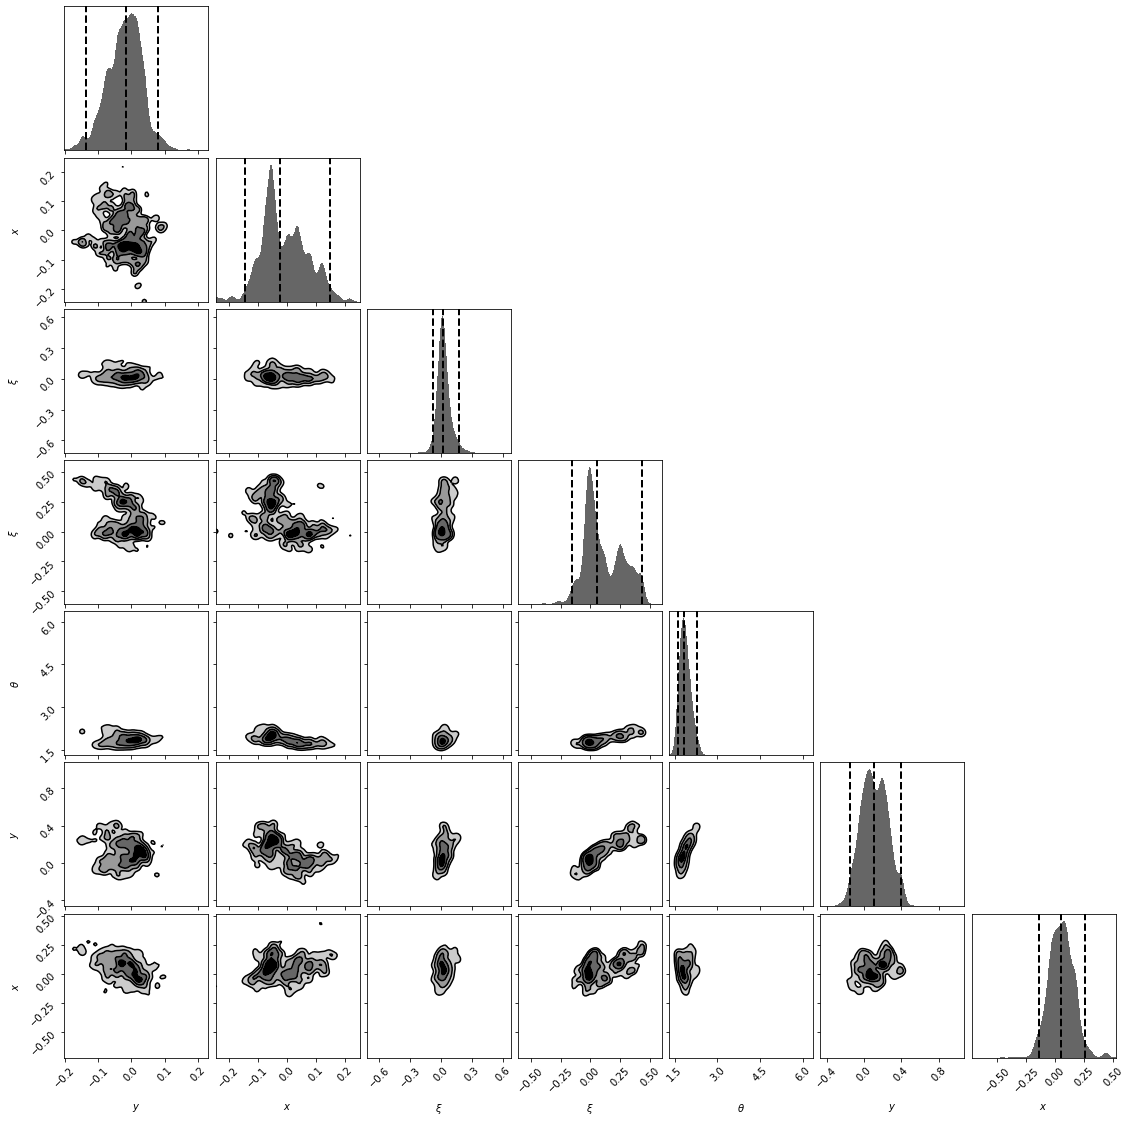

In [12]:
tracer_plotter = aplt.TracerPlotter(
    tracer=result.max_log_likelihood_tracer, grid=result.grid
)
tracer_plotter.subplot_tracer()

dynesty_plotter = aplt.DynestyPlotter(samples=result.samples)
dynesty_plotter.cornerplot()

## CS82SL015824.81-003959.60

In [13]:
img_name = "imgblock2.fits"
sys_path = "./LOG/sys_2/"

### Lens System

In [14]:
images = [[86.605103, 92.186736], [71.534694, 92.186736], [53.673468, 78.511735]]
noise_map = [0.05, 0.5, 0.5]

image_pos = prepare_data(images)

In [15]:
image = al.Array2D.from_fits(
    file_path=imgblocks_paths+img_name, pixel_scales=grid_scale, hdu=3
)

In [16]:
image_pos_cat = al.PointDataset(name="point_0",
                                positions = al.Grid2DIrregular(image_pos),
                                positions_noise_map = al.ValuesIrregular(noise_map)
                        )

point_dict = al.PointDict(point_dataset_list=[image_pos_cat])

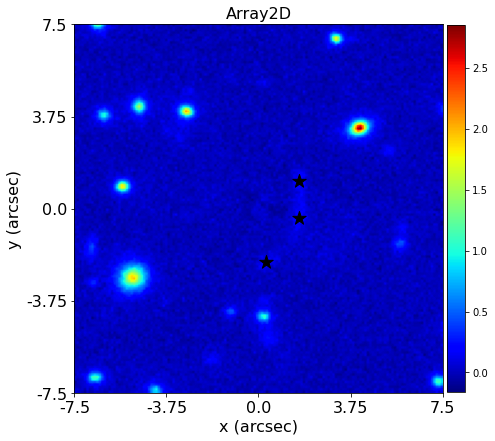

In [17]:
visuals_2d = aplt.Visuals2D(positions=point_dict.positions_list)

array_plotter = aplt.Array2DPlotter(array=image, visuals_2d=visuals_2d)
array_plotter.figure_2d()

### Inverse modeling

In [18]:
# lens model
lens = af.Model(al.Galaxy, redshift=0.53, mass=al.mp.EllIsothermal)
# source model
source = af.Model(al.Galaxy, redshift=1.0, point_0=al.ps.Point)
# model
model = af.Collection(galaxies=af.Collection(lens=lens, source=source))

In [19]:
# commom 2d grid, it uses the image's grid
grid = al.Grid2D.uniform(
    shape_native=image.shape_native, pixel_scales=image.pixel_scales
)
# looks like an initial guess for our image positions
positions_solver = al.PositionsSolver(grid=grid, pixel_scale_precision=0.1)

In [20]:
# model path and cores for fit
search = af.DynestyStatic(
    path_prefix="./",
    name="sys2",
    nlive=50,
    number_of_cores=4,
)

2021-07-19 14:43:43,029 - sys2 - INFO - Creating search


In [21]:
# fit our model
analysis = al.AnalysisPoint(point_dict=point_dict, solver=positions_solver)
result = search.fit(model=model, analysis=analysis)

2021-07-19 14:43:43,117 - sys2 - INFO - Starting search
2021-07-19 14:43:43,333 - sys2 - INFO - Already completed, skipping non-linear search.
2021-07-19 14:43:43,347 - sys2 - INFO - Removing zip file


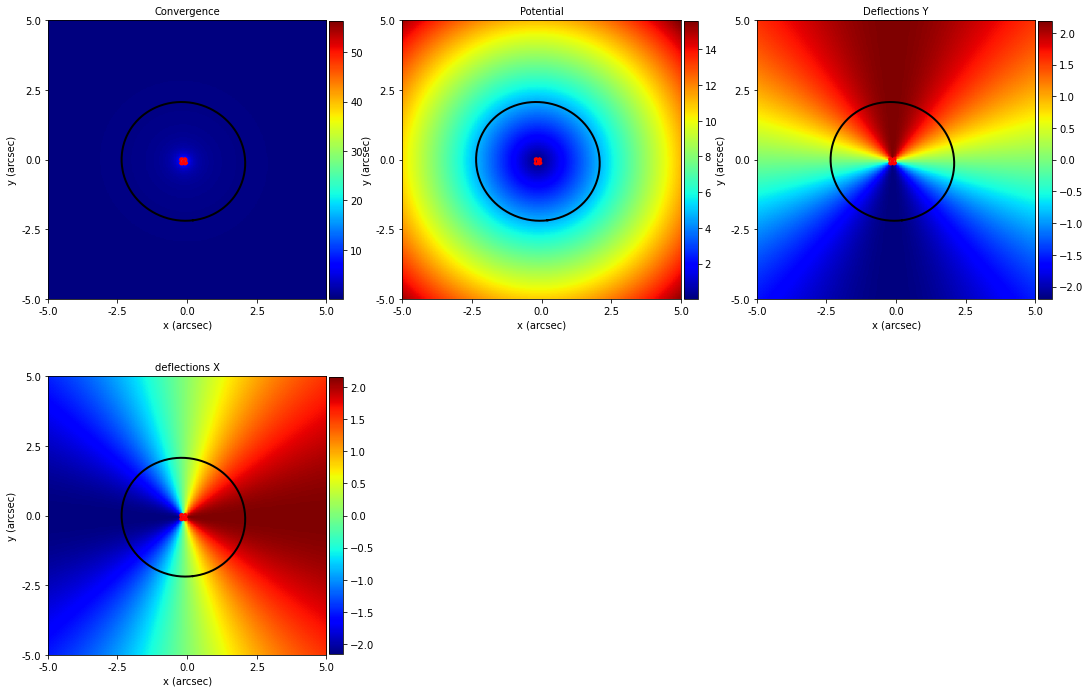

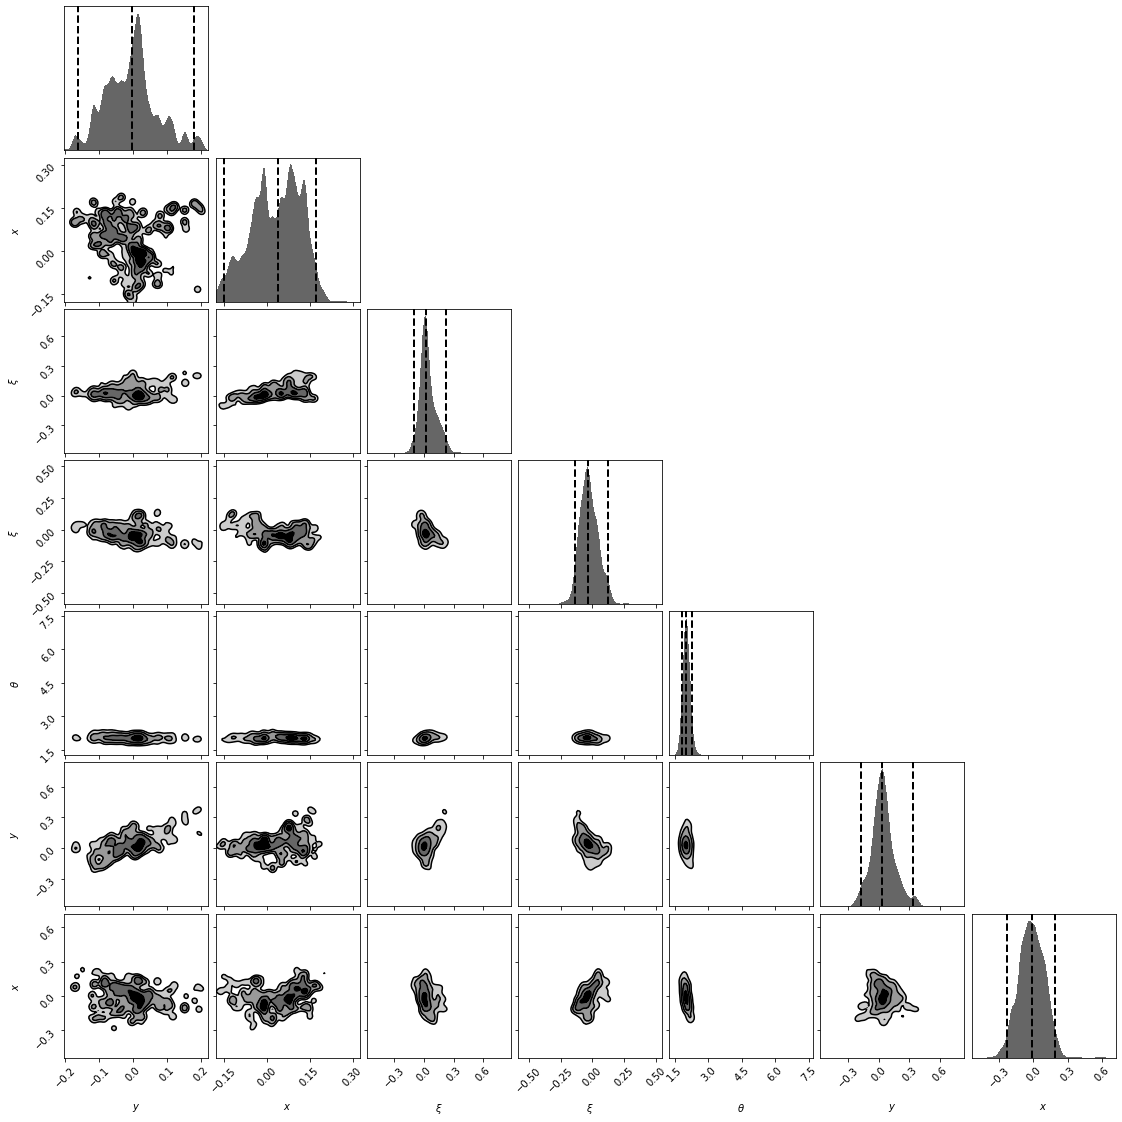

In [22]:
tracer_plotter = aplt.TracerPlotter(
    tracer=result.max_log_likelihood_tracer, grid=result.grid
)
tracer_plotter.subplot_tracer()

dynesty_plotter = aplt.DynestyPlotter(samples=result.samples)
dynesty_plotter.cornerplot()

## CS82SL211527.25-003817.26


In [23]:
img_name = "imgblock3.fits"
sys_path = "./LOG/sys_3_ci/"

### Lens System

In [24]:
images = [[86.326021, 78.232653], [82.69796, 66.232142], [70.139285, 65.953061], [67.627551, 86.605103]]
noise_map = [0.05, 0.5, 0.5, 0.5]

image_pos = prepare_data(images)

In [25]:
image = al.Array2D.from_fits(
    file_path=imgblocks_paths+img_name, pixel_scales=grid_scale, hdu=3
)

In [26]:
image_pos_cat = al.PointDataset(name="point_0",
                                positions = al.Grid2DIrregular(image_pos),
                                positions_noise_map = al.ValuesIrregular(noise_map)
                        )

point_dict = al.PointDict(point_dataset_list=[image_pos_cat])

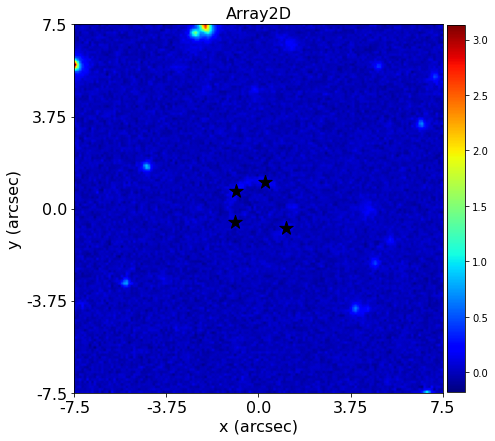

In [27]:
visuals_2d = aplt.Visuals2D(positions=point_dict.positions_list)

array_plotter = aplt.Array2DPlotter(array=image, visuals_2d=visuals_2d)
array_plotter.figure_2d()

### Inverse modeling

In [28]:
# lens model
lens = af.Model(al.Galaxy, redshift=0.59, mass=al.mp.EllIsothermal)
# source model
source = af.Model(al.Galaxy, redshift=1.0, point_0=al.ps.Point)
# model
model = af.Collection(galaxies=af.Collection(lens=lens, source=source))

In [29]:
# commom 2d grid, it uses the image's grid
grid = al.Grid2D.uniform(
    shape_native=image.shape_native, pixel_scales=image.pixel_scales
)
# looks like an initial guess for our image positions
positions_solver = al.PositionsSolver(grid=grid, pixel_scale_precision=0.1)

In [30]:
# model path and cores for fit
search = af.DynestyStatic(
    path_prefix="./",
    name="sys3",
    nlive=50,
    number_of_cores=4,
)

2021-07-19 14:44:01,273 - sys3 - INFO - Creating search


In [31]:
# fit our model
analysis = al.AnalysisPoint(point_dict=point_dict, solver=positions_solver)
result = search.fit(model=model, analysis=analysis)

2021-07-19 14:44:01,340 - sys3 - INFO - Starting search
2021-07-19 14:44:01,570 - sys3 - INFO - Already completed, skipping non-linear search.
2021-07-19 14:44:01,586 - sys3 - INFO - Removing zip file


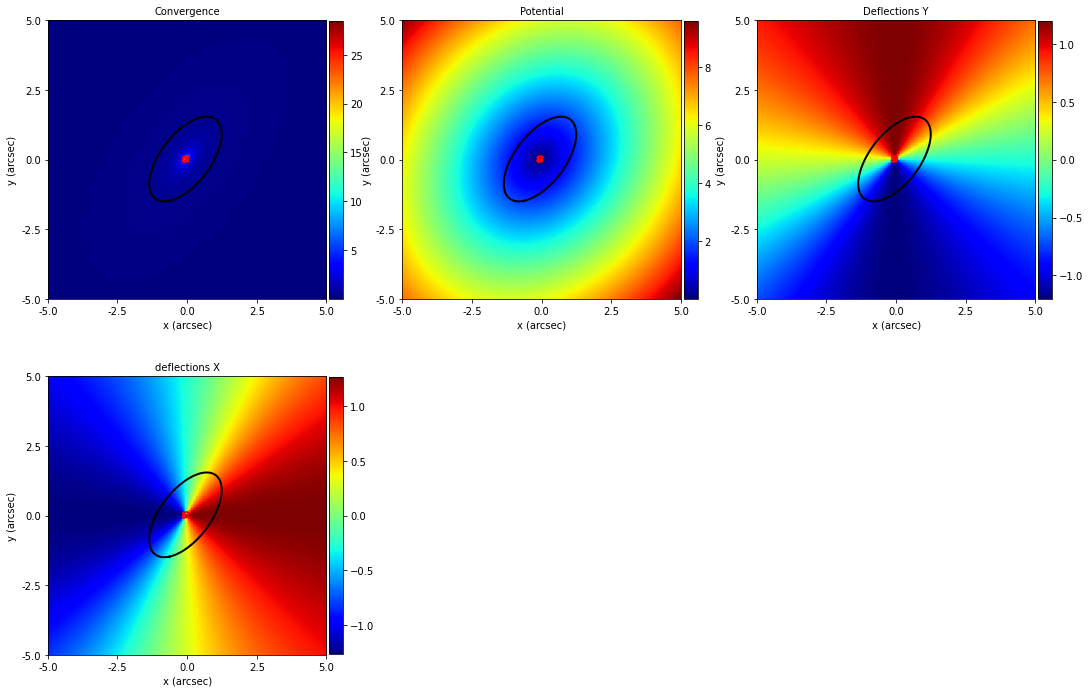

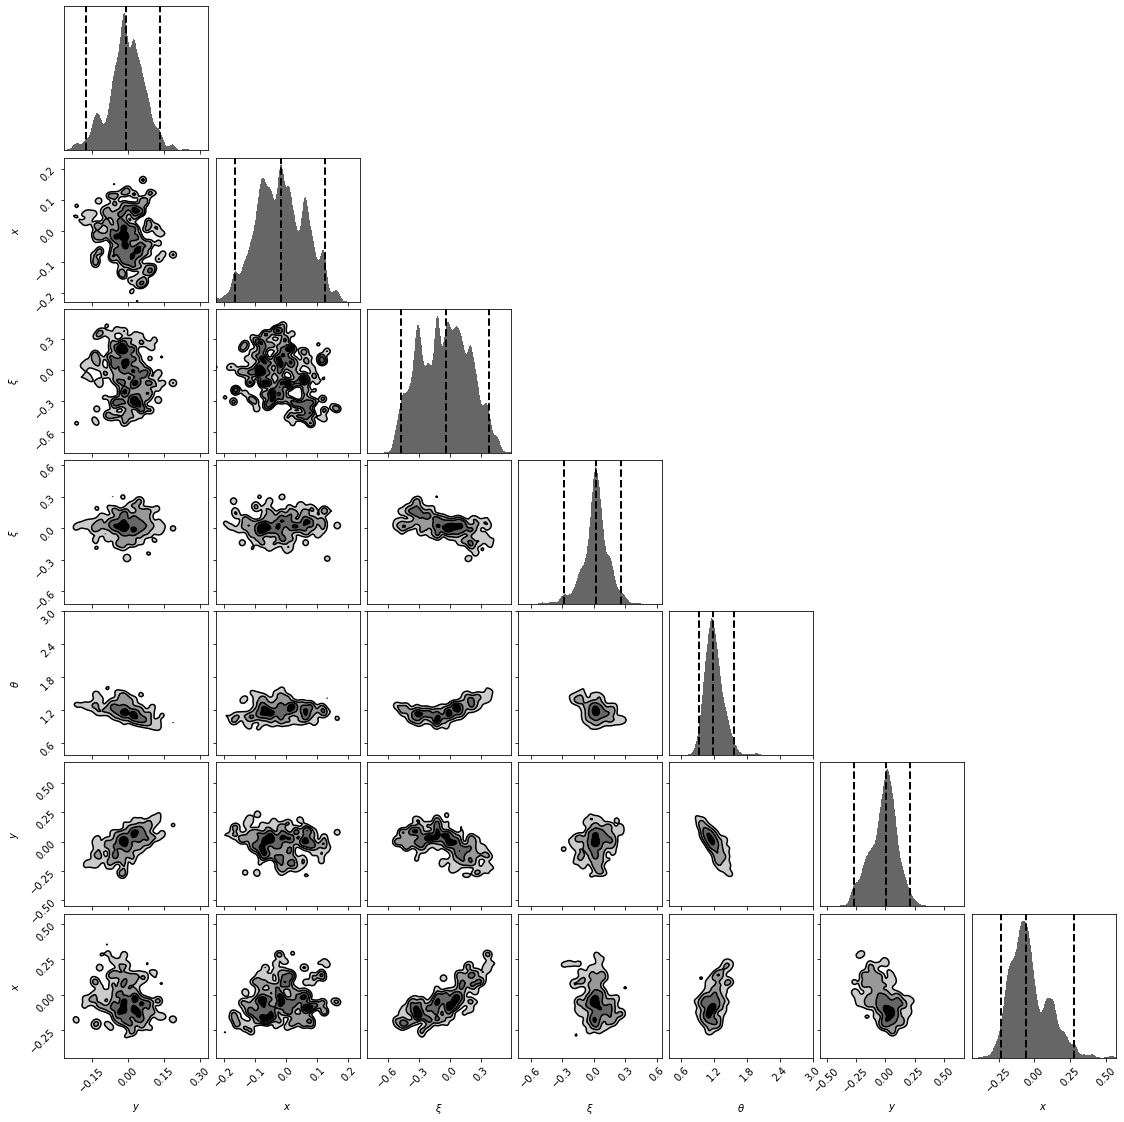

In [32]:
tracer_plotter = aplt.TracerPlotter(
    tracer=result.max_log_likelihood_tracer, grid=result.grid
)
tracer_plotter.subplot_tracer()

dynesty_plotter = aplt.DynestyPlotter(samples=result.samples)
dynesty_plotter.cornerplot()

## CS82SL230521.68-000211.52

In [33]:
img_name = "imgblock4.fits"
sys_path = "./LOG/sys_4/"

### Lens system

In [34]:
images = [[84.372449, 79.721089], [73.67432, 85.767858], [66.929846, 82.279337], [74.139456, 68.325255]]
noise_map = [0.05, 0.5, 0.5, 0.5]

image_pos = prepare_data(images)

In [35]:
image = al.Array2D.from_fits(
    file_path=imgblocks_paths+img_name, pixel_scales=grid_scale, hdu=3
)

In [36]:
image_pos_cat = al.PointDataset(name="point_0",
                                positions = al.Grid2DIrregular(image_pos),
                                positions_noise_map = al.ValuesIrregular(noise_map)
                        )

point_dict = al.PointDict(point_dataset_list=[image_pos_cat])

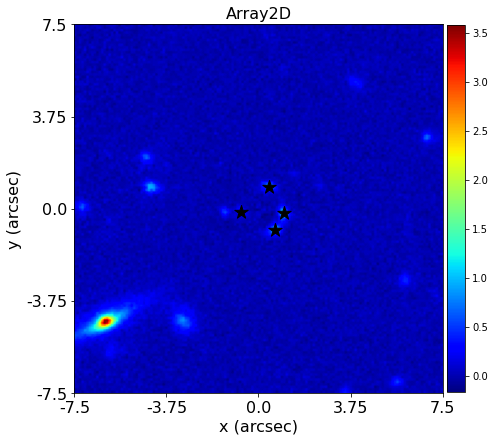

In [37]:
visuals_2d = aplt.Visuals2D(positions=point_dict.positions_list)

array_plotter = aplt.Array2DPlotter(array=image, visuals_2d=visuals_2d)
array_plotter.figure_2d()

### Inverse modeling

In [38]:
# lens model
lens = af.Model(al.Galaxy, redshift=0.53, mass=al.mp.EllIsothermal)
# source model
source = af.Model(al.Galaxy, redshift=1.0, point_0=al.ps.Point)
# model
model = af.Collection(galaxies=af.Collection(lens=lens, source=source))

In [39]:
# commom 2d grid, it uses the image's grid
grid = al.Grid2D.uniform(
    shape_native=image.shape_native, pixel_scales=image.pixel_scales
)
# looks like an initial guess for our image positions
positions_solver = al.PositionsSolver(grid=grid, pixel_scale_precision=0.1)

In [40]:
# model path and cores for fit
search = af.DynestyStatic(
    path_prefix="./",
    name="sys4",
    nlive=50,
    number_of_cores=4,
)

2021-07-19 14:44:19,673 - sys4 - INFO - Creating search


In [41]:
# fit our model
analysis = al.AnalysisPoint(point_dict=point_dict, solver=positions_solver)
result = search.fit(model=model, analysis=analysis)

2021-07-19 14:44:19,796 - sys4 - INFO - Starting search
2021-07-19 14:44:20,083 - sys4 - INFO - Already completed, skipping non-linear search.
2021-07-19 14:44:20,104 - sys4 - INFO - Removing zip file


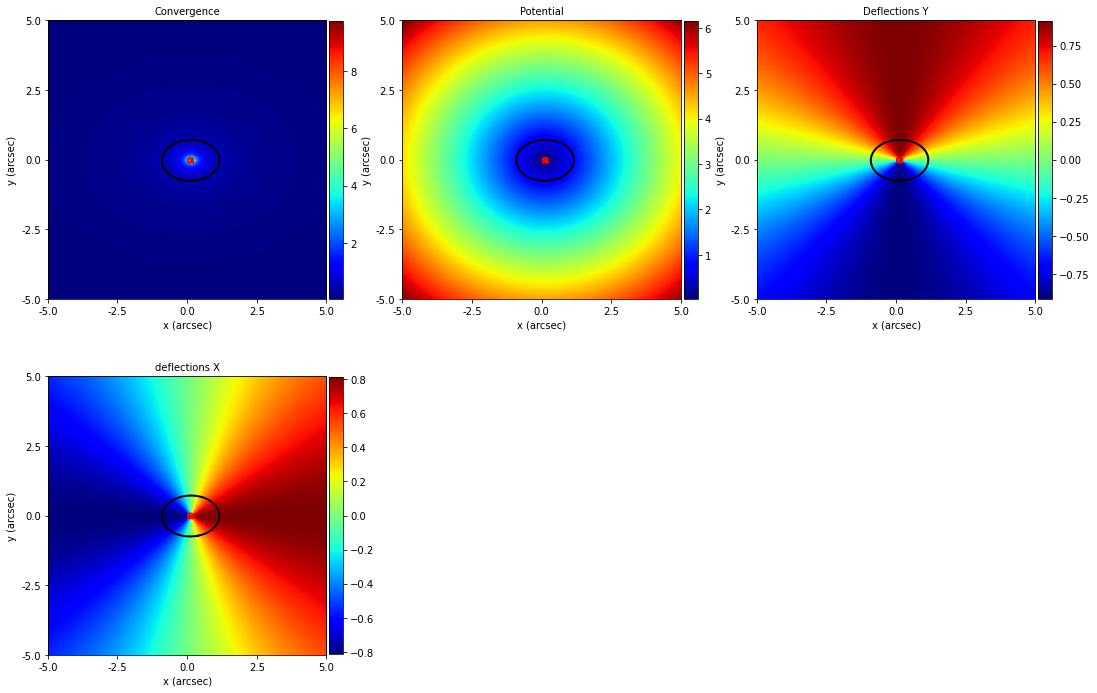

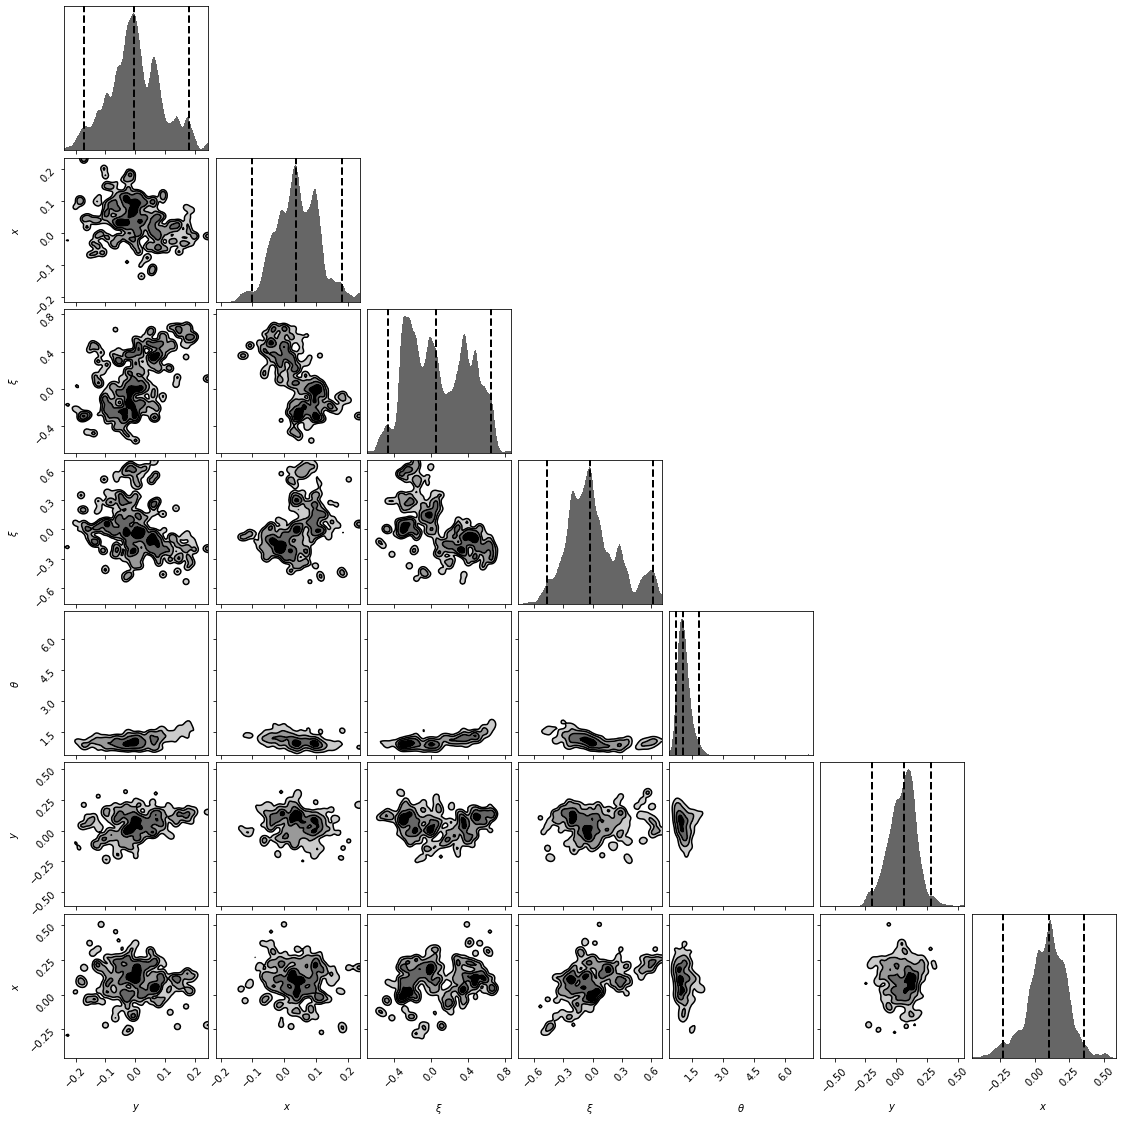

In [42]:
tracer_plotter = aplt.TracerPlotter(
    tracer=result.max_log_likelihood_tracer, grid=result.grid
)
tracer_plotter.subplot_tracer()

dynesty_plotter = aplt.DynestyPlotter(samples=result.samples)
dynesty_plotter.cornerplot()